# Finding Traveling Waves
2025-11-18

This notebook shows the procedure for finding a traveling wave solution to the Navier-Stokes.

The naming here -- TW1 -- is based off of this paper: https://arxiv.org/pdf/0808.3375

In [1]:
using LinearAlgebra, Polynomials, Plots
using Revise, DelimitedFiles, BenchmarkTools
using CloudAtlas, BifurcationKit, ChannelflowWrapper

"""
    myreaddlm(filename, cc='%')

Read matrix or vector from a file, dropping comments marked with cc.
"""
function myreaddlm(filename; cc='%')
    X = readdlm(filename, comments=true, comment_char=cc)
    if size(X,2) == 1
        X = X[:,1]
    end
    X
end

macro suppress(ex)
    quote
        # Generate a unique name for the old stdout to avoid variable collision
        local old_stdout = stdout
        redirect_stdout(devnull)
        try
            # We use esc(ex) to run the expression in the caller's scope
            $(esc(ex))
        finally
            redirect_stdout(old_stdout)
        end
    end
end

sx, sy, sz, tx, tz = halfbox_symmetries()

pwd()

"/home/ebenq/Dev/julia/CloudAtlas.jl/notebooks/tw_bifurcations"

## Finding a Traveling Wave Solution

In [2]:
# Parameters
hookparams = SearchParams(ftol=1e-08, xtol=1e-12, Nnewton=30,Nhook=8,δ=0.01, verbosity=0)
R = 200
cx0 = 0.000 # values from paper
cz0 = 0.009

α, γ = 1.0, 2.0                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
H = [(sx*sy)*(tx*tz)]               # Generators of the symmetric subspace of TW1
normalize = true                    # Normalize the basis set or not?

# The DNS file to project from (ensure this path is correct)
dns_file = "TW1-2pi1piRe200-40x49x40.nc" 

# List of resolutions to test: [(J, K, L), ...]
# discretizations = [(1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 3), (1, 3, 5), (2, 4, 7), (3, 5, 9)]
discretizations = [(1, 1, 2), (1, 1, 3), (1, 2, 3), (1, 3, 5), (2, 4, 7)]
# discretizations = [(1, 1, 3), (1, 2, 3), (1, 3, 5), (2, 4, 7)]
# discretizations = [(1, 1, 3), (1, 2, 3)]


6-element Vector{Tuple{Int64, Int64, Int64}}:
 (1, 1, 1)
 (1, 1, 2)
 (1, 1, 3)
 (1, 2, 3)
 (1, 3, 5)
 (2, 4, 7)

## 2. Bifurcation Analysis

In [3]:
"""
Continue a z-traveling wave (cx=0) solution branch in Reynolds number.
"""
function tw_z_branch_continuation(model, ξ_0, Re0;
                                  Re_min=100.0, Re_max=500.0,
                                  max_steps=1000, tol=1e-10, dsmin=1e-7)
    m = model.m
    x0 = ξ_0[1:m]
    cx0 = ξ_0[m+1]
    cz0 = ξ_0[m+2]
    
    # Pack state as [x; cz]
    u0 = vcat(x0, cz0) # State vector is length n+1
    
    # Define the fixed phase condition vector
    Du0_z = model.Cz * x0
    
    # Define residual function
    function f_tw_z(u, p)
        (; Re) = p
        x  = u[1:m]
        cz = u[end] 

        # Standard residual
        res_flow = (cz .* (model.Cz * x)) .- (model.A1 * x) .- ((1/Re) .* (model.A2 * x)) .- model.N(x)
        
        # Compute phase condition
        res_phase = dot(x .- x0, Du0_z)
        
        # Return combined vector
        return [res_flow; res_phase]
    end

    # Set up bifurcation problem
    params = (Re = Re0, x0_param = x0, Du0_param = Du0_z)
    
    prob = BifurcationProblem(
        f_tw_z, u0, params, (@optic _.Re);
        record_from_solution = (u, p_val; k...) -> (R=p_val, x=u[1:m], cx=0.0, cz=u[m+1], pow=shear(u[1:m], model))
    )
    
    # Continuation options
    opts = ContinuationPar(
        p_max=Re_max,
        p_min=Re_min,
        detect_bifurcation = 0, # Skip expensive stability/eigenvalue checks for speed
        n_inversion=20,
        max_steps=max_steps,
        newton_options=NewtonPar(tol=tol, max_iterations=20),
        dsmin=dsmin
    )
    
    println("Starting Z-TW continuation from Re = $Re0...")
    branch = continuation(prob, PALC(), opts, bothside=true)
    println("Continuation complete. Found $(length(branch.branch)) points.")
    return branch
end


tw_z_branch_continuation

In [4]:
function compute_branch(J, K, L, udns_file; Re_start=200.0, α=1.0, γ=2.0, H=[(sx*sy)*(tx*tz)])
    model = TWModel(α, γ, J, K, L, H, normalize=true)
    m = length(model)
    println("Model dimension m = $m")

    #  Generate Initial Guess (Project DNS onto THIS basis)
    filename_guess = "tmp_projection_J$(J)K$(K)L$(L).asc"
    x0 = field2coeff(model.ijkl, udns_file, filename_guess)
    # Construct state vector ξ = [x; cx; cz]
    cx0, cz0 = 0.000, 0.009
    ξ0 = [x0; cx0; cz0]

    # 3. Solve for Fixed Point (Newton/Hookstep) at Re_start
    println("Finding fixed point at Re=$Re_start...")
    
    g_closure(ξ) = model.g(ξ, Re_start)
    Dg_closure(ξ) = model.Dg(ξ, Re_start)
    
    ξ_final, converged = hookstepsolve(g_closure, Dg_closure, ξ0, hookparams)
    
    if !converged
        println("WARNING: Newton solver did not converge for $J,$K,$L")
        return nothing
    end

    # Run Continuation
    println("Running continuation...")
    branch = tw_z_branch_continuation(model, ξ_final, Re_start; 
                                    Re_min=100.0, Re_max=500.0, max_steps=1000)
    
    return branch
end

compute_branch (generic function with 1 method)

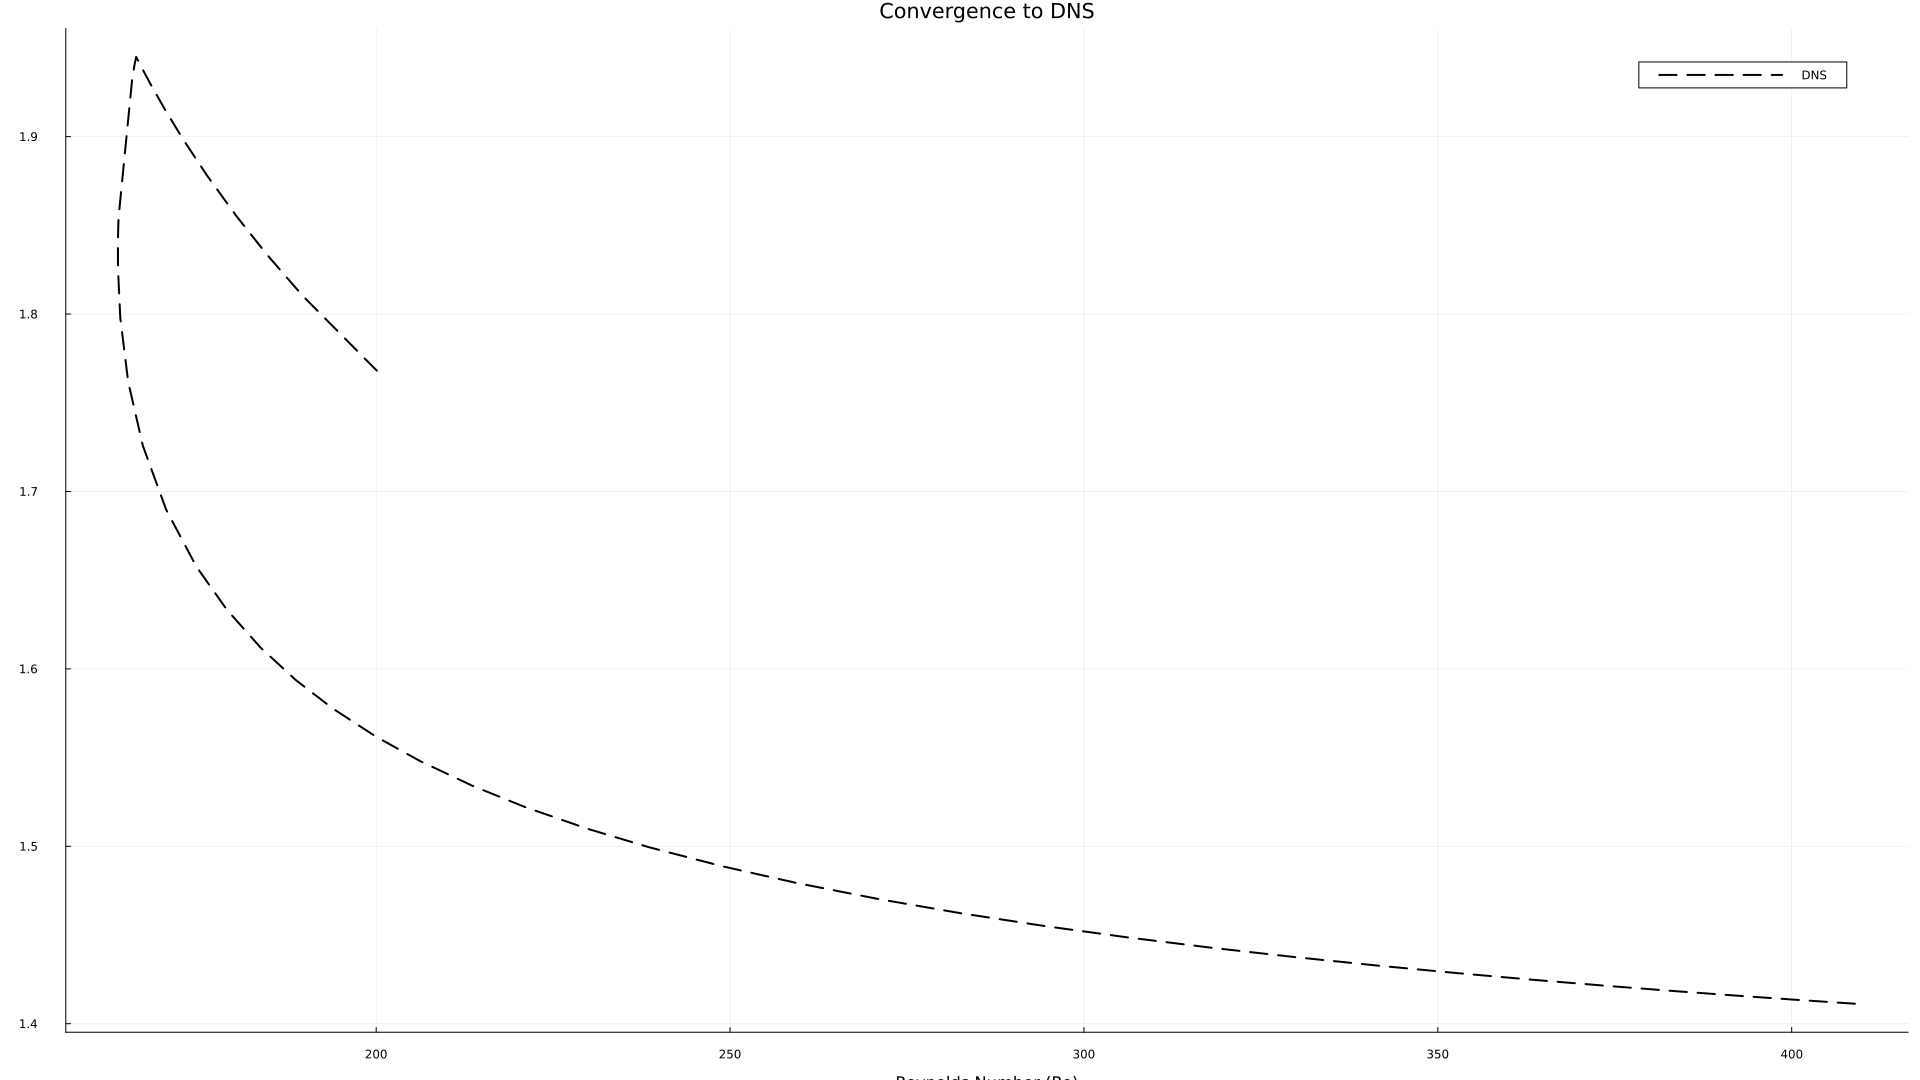

In [5]:
# --- Plotting ---
p = plot(
    xlabel = "Reynolds Number (Re)",
    ylabel = "Power Input",
    title = "Convergence to DNS",
    legend = :topright,
    grid = true,
    size=(1920, 1080)
)

# Plot DNS Data
if isfile("tw1Re-DNS.asc")
    dns_data = myreaddlm("tw1Re-DNS.asc")
    plot!(p, dns_data[:,1], dns_data[:,2], 
        label="DNS", color=:black, linewidth=2, linestyle=:dash)
end


Starting analysis for Resolution: J=1, K=1, L=1
Branch complete!


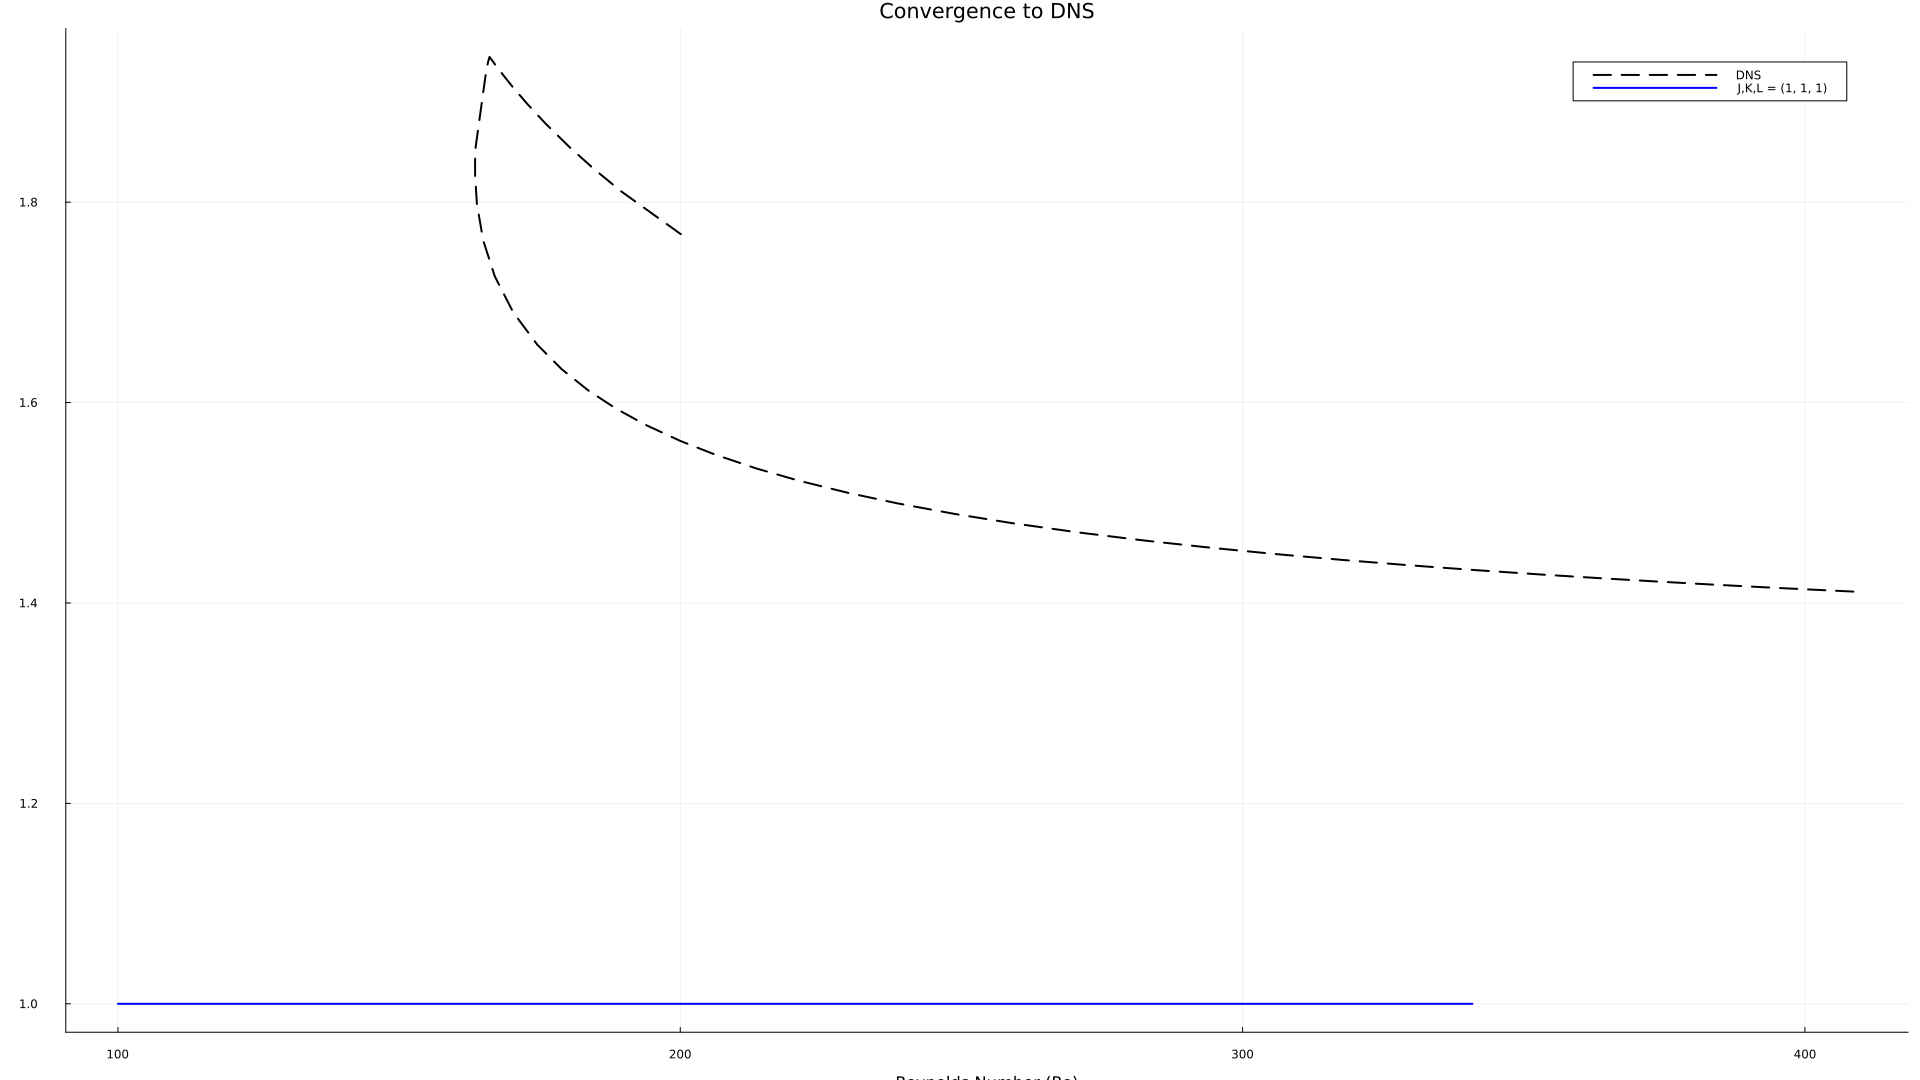


Starting analysis for Resolution: J=1, K=1, L=2
Branch complete!


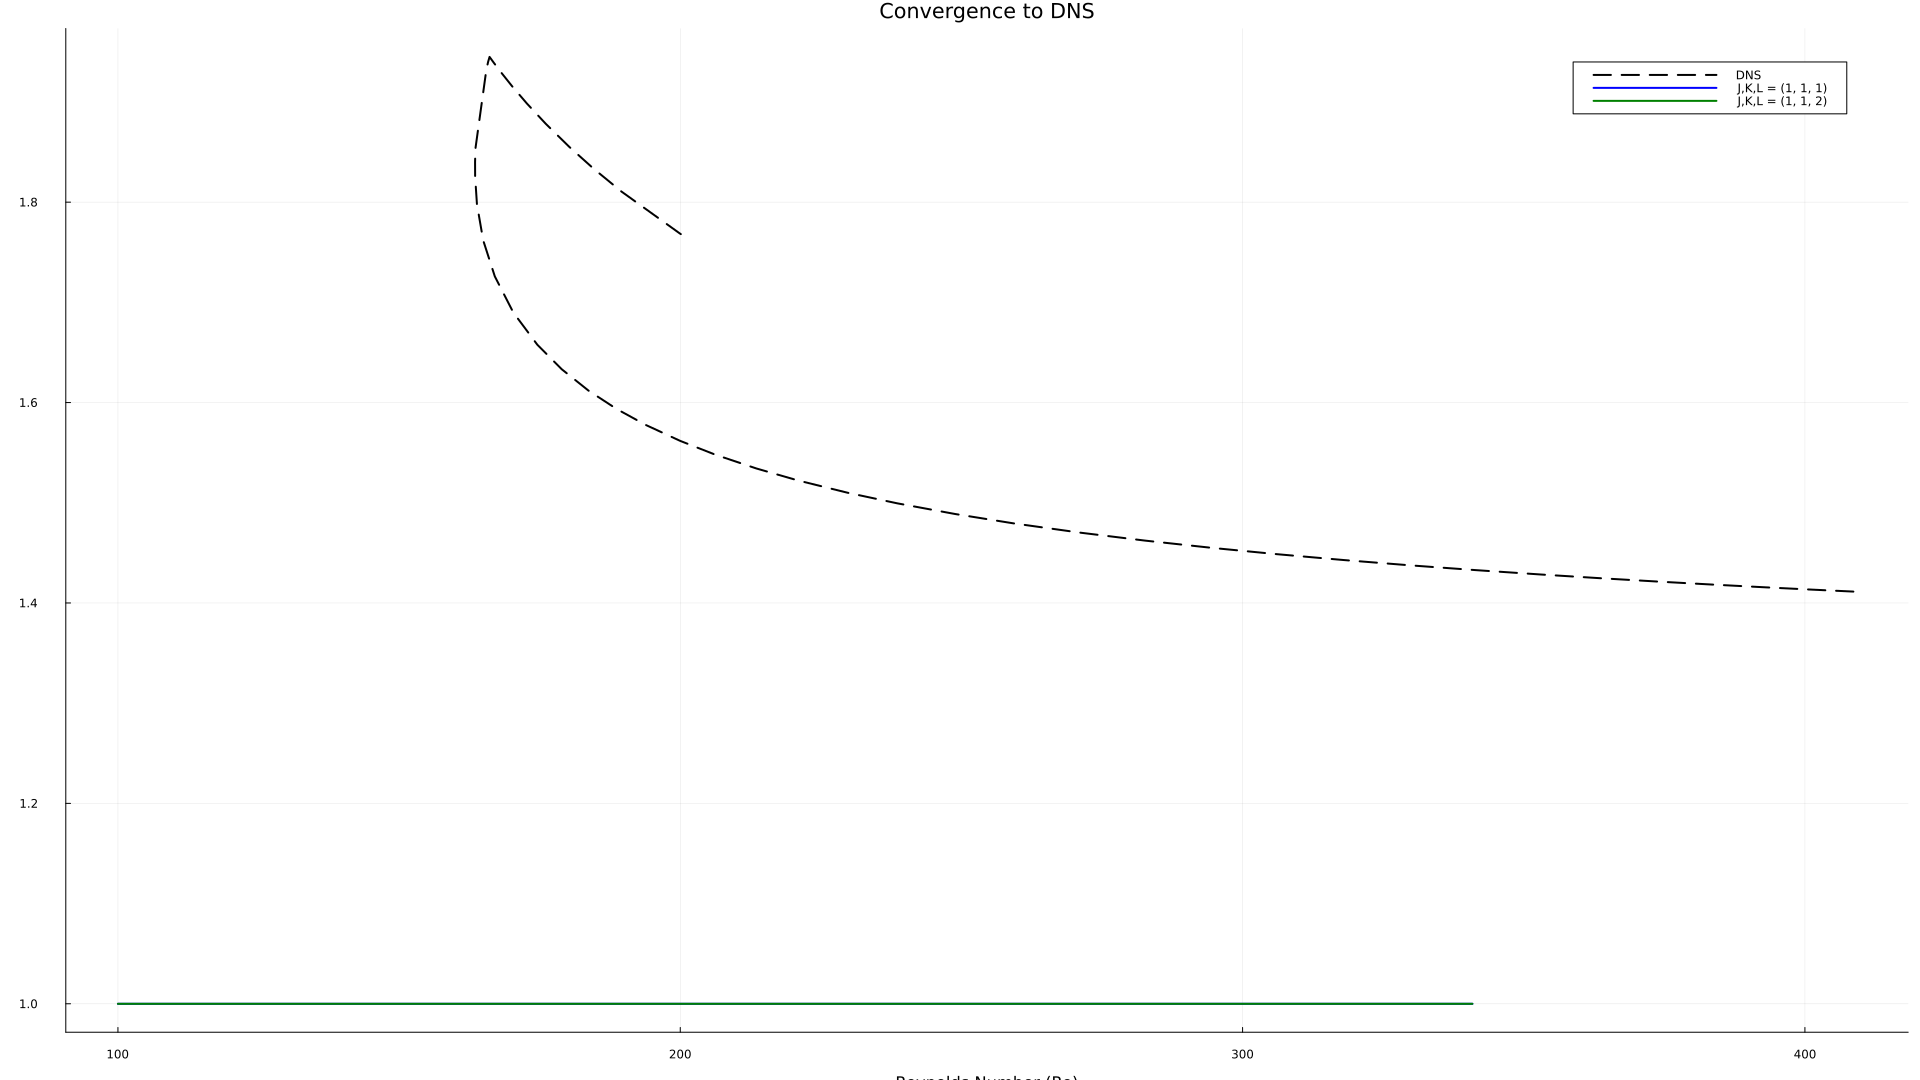


Starting analysis for Resolution: J=1, K=1, L=3
Branch complete!


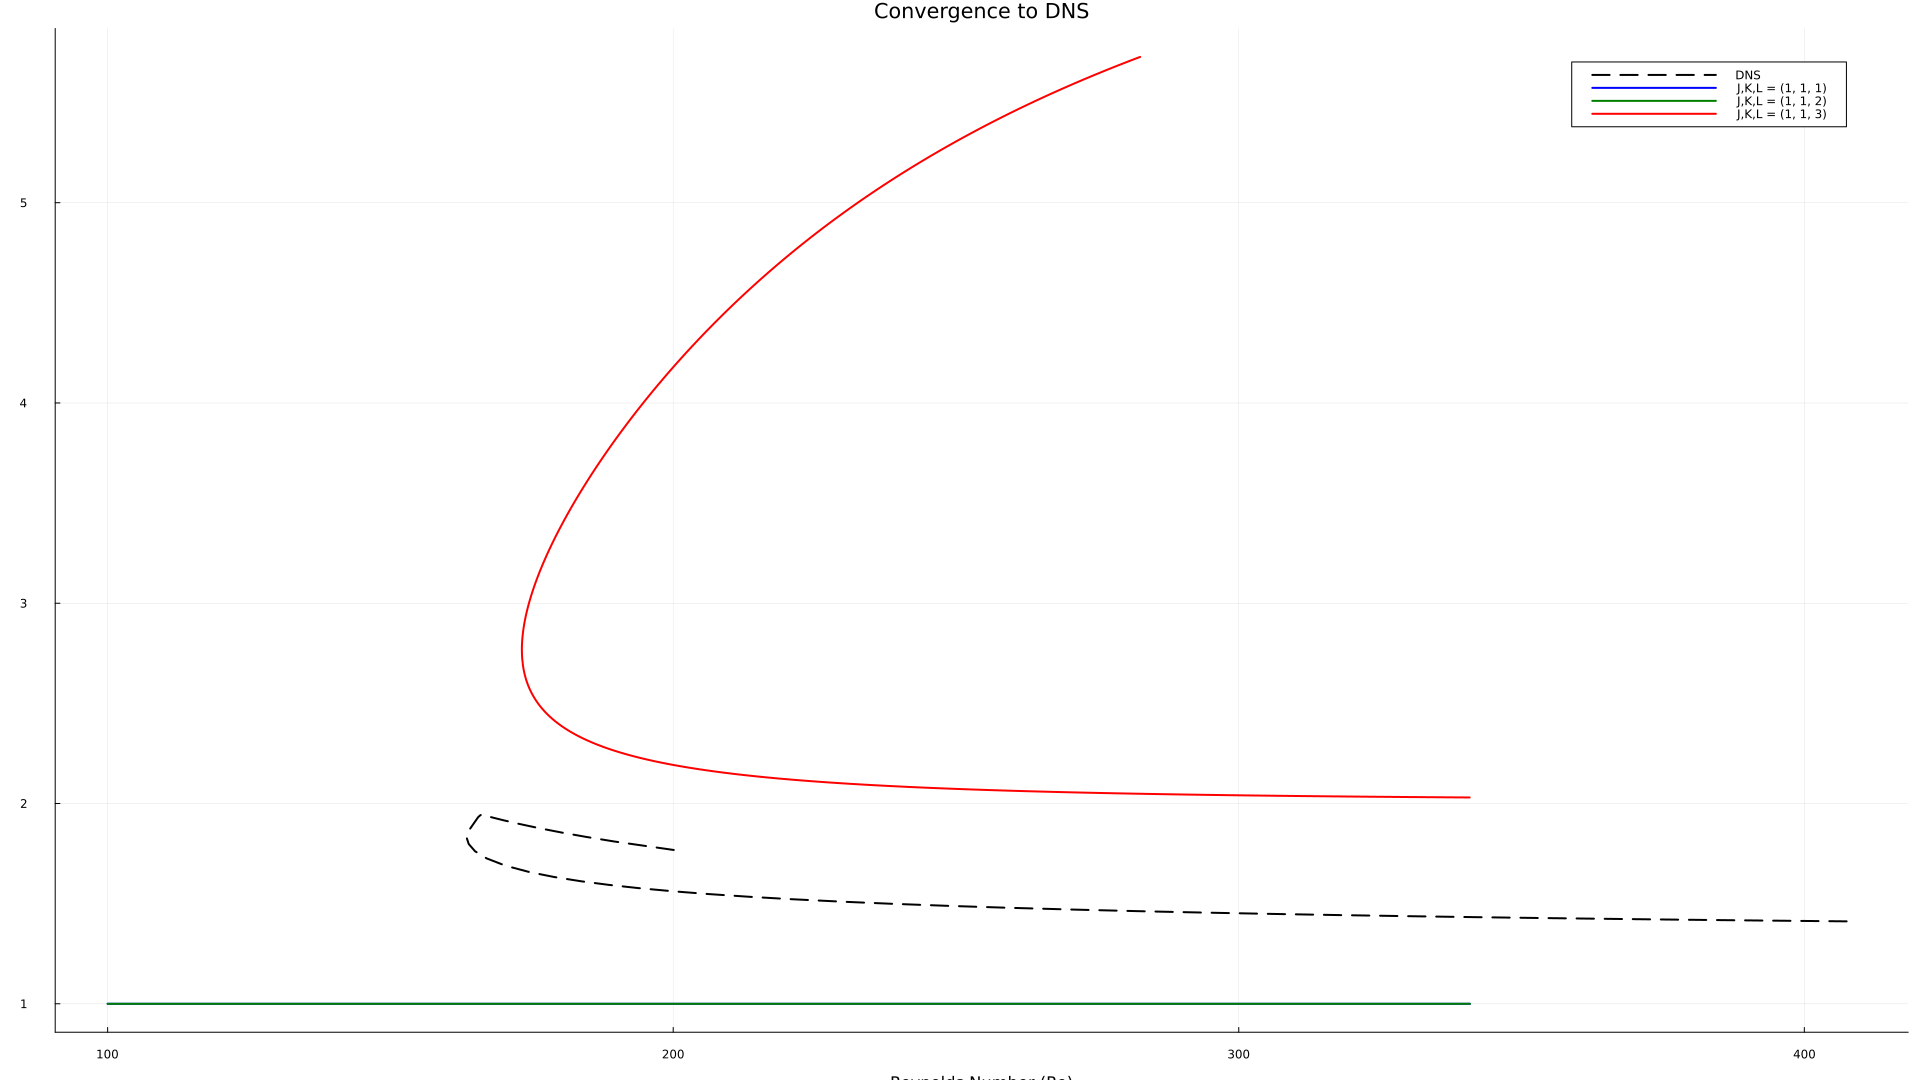


Starting analysis for Resolution: J=1, K=2, L=3


┌ Error: Failure to converge with given tolerance = 1.0e-10.
│ Step = 921
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 1.0e-7.
│ Stopping continuation at continuation step 921.
└ @ BifurcationKit ~/.julia/packages/BifurcationKit/H9RbT/src/continuation/Contbase.jl:70


Branch complete!


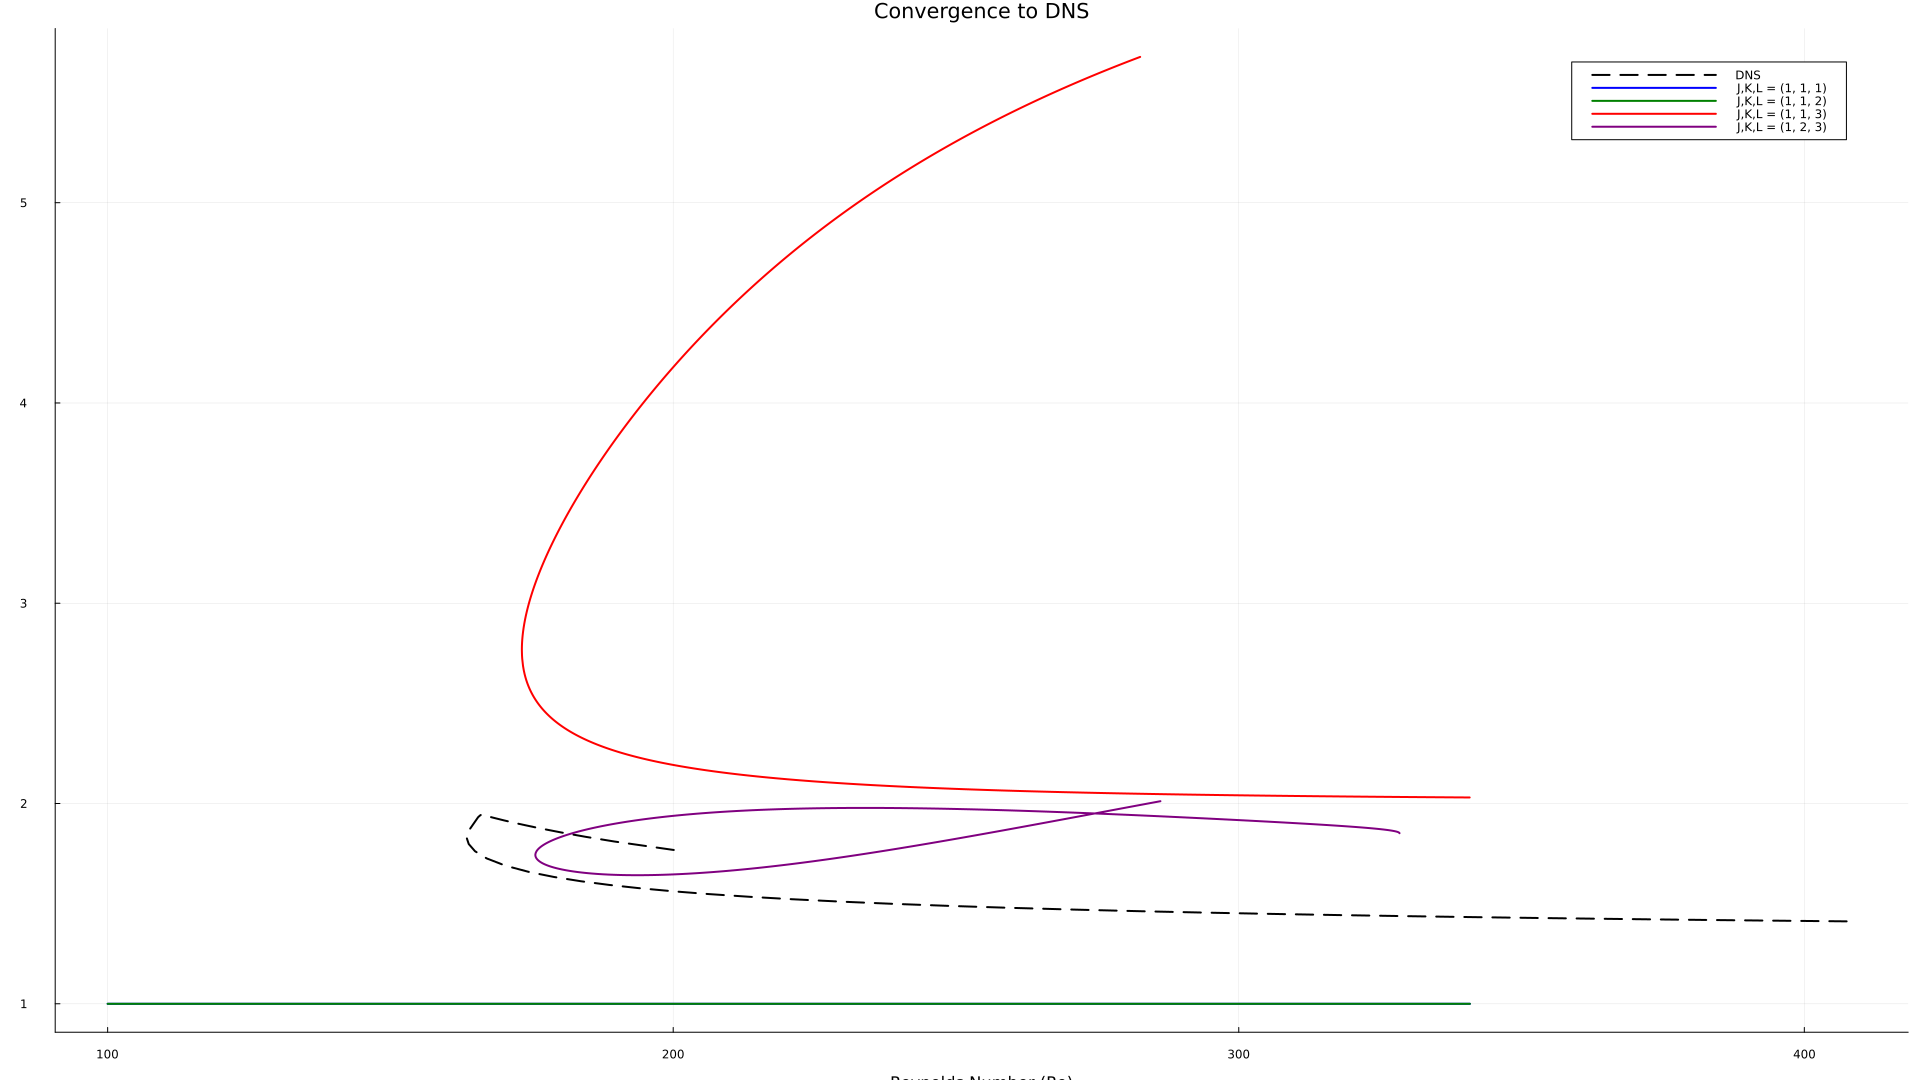


Starting analysis for Resolution: J=1, K=3, L=5
Branch complete!


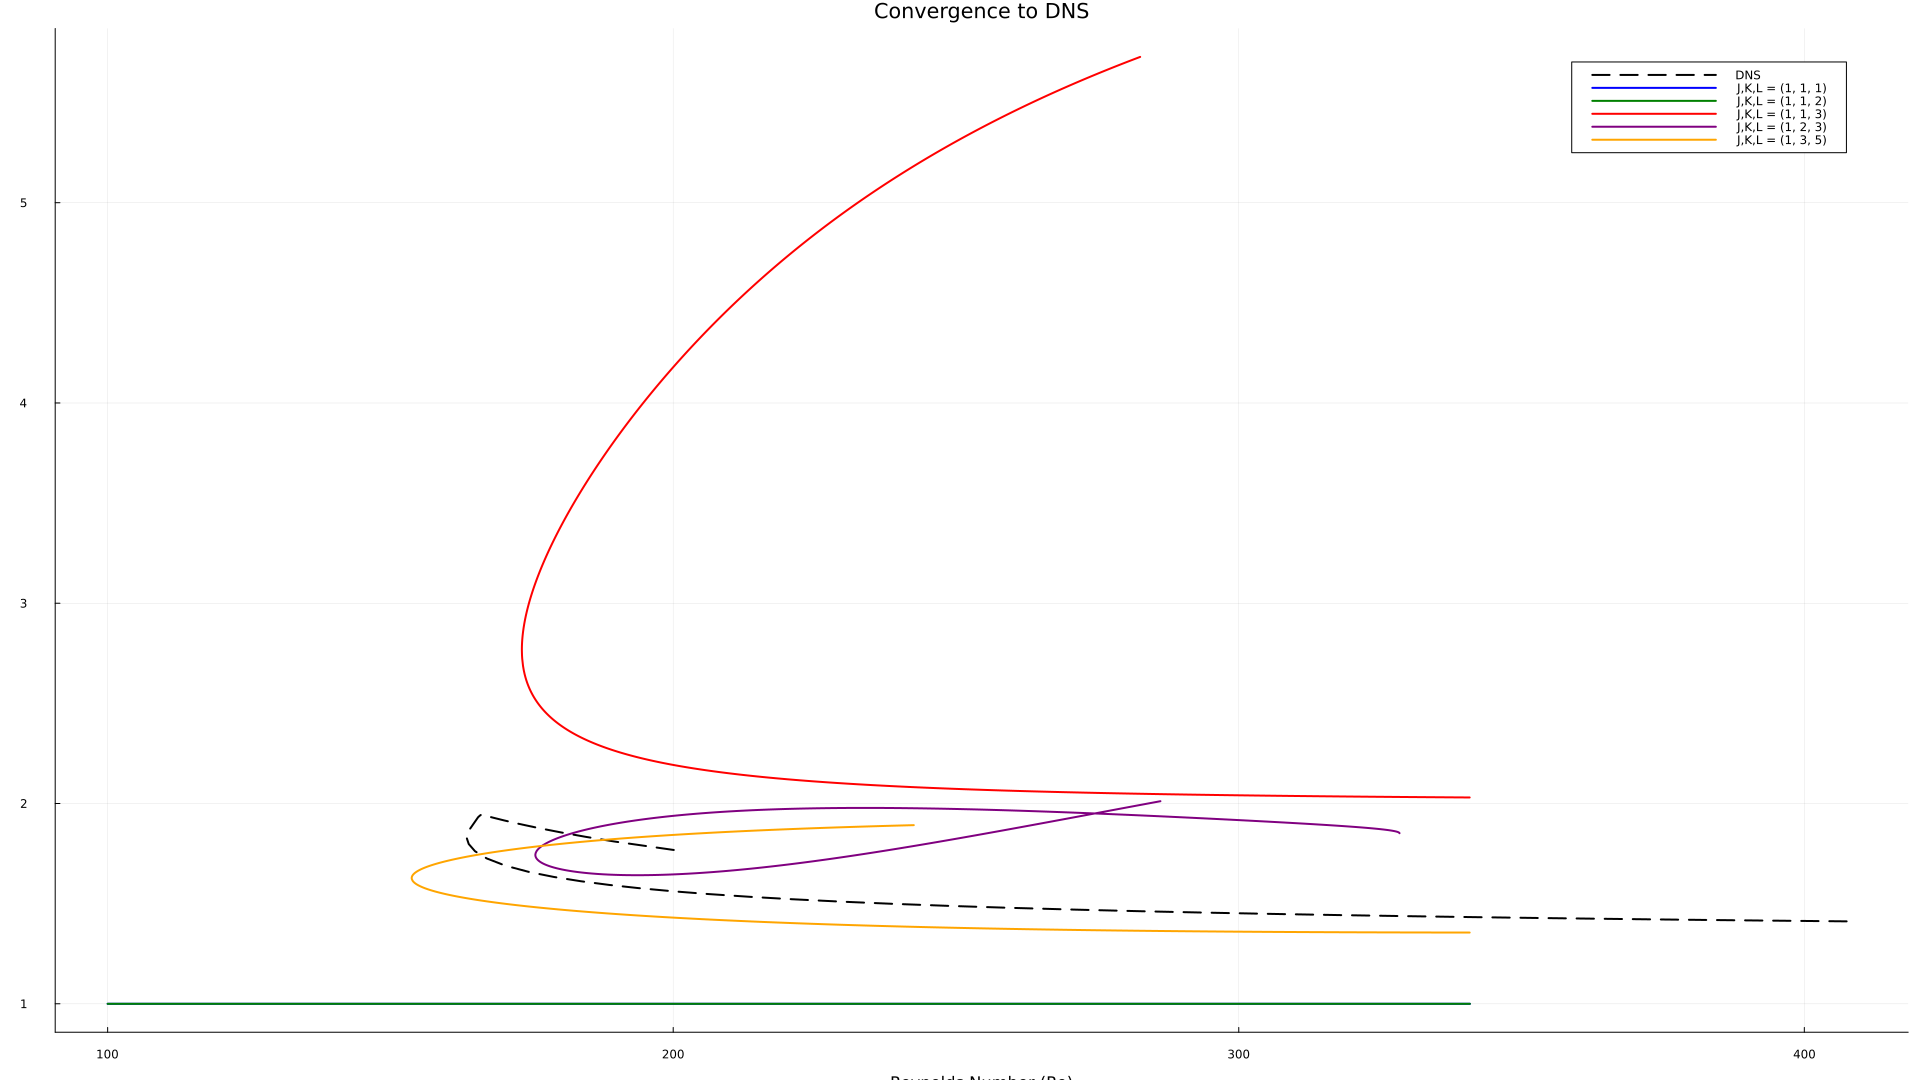


Starting analysis for Resolution: J=2, K=4, L=7
Branch complete!


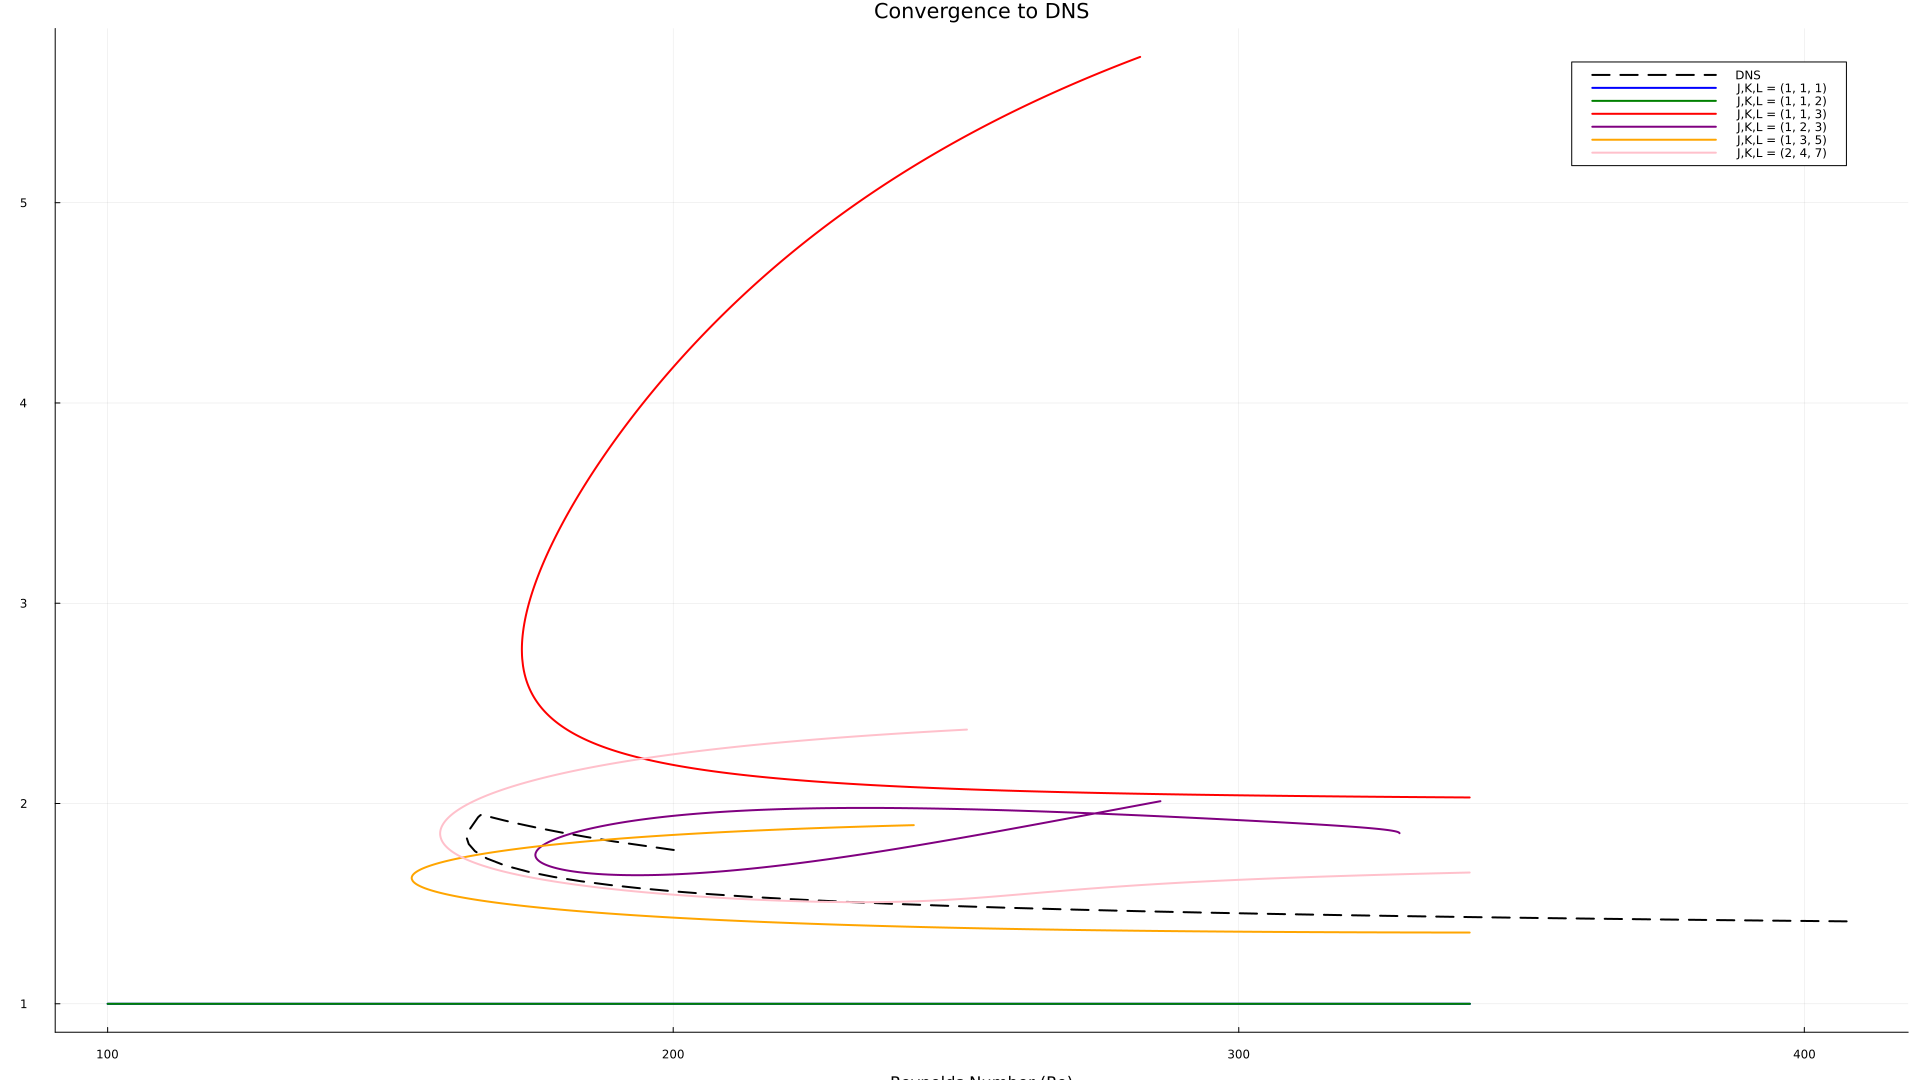

In [8]:
# Storage for results
branches = Dict()

colors = [:blue, :green, :red, :purple, :orange, :pink, :teal]
for (i, jkl) in enumerate(discretizations)
    J, K, L = jkl
    println("\n" * "="^60)
    println("Starting analysis for Resolution: J=$J, K=$K, L=$L")
    println("="^60)
    br = @suppress compute_branch(J, K, L, dns_file)
    println("Branch complete!")
    if br !== nothing
        branches[(J,K,L)] = br
        
        # Plot the branch
        plot!(p, br.param, br.pow, 
            label="J,K,L = $jkl", 
            linewidth=2, 
            color=colors[mod1(i, length(colors))]
        )
    end
    display(p)
end

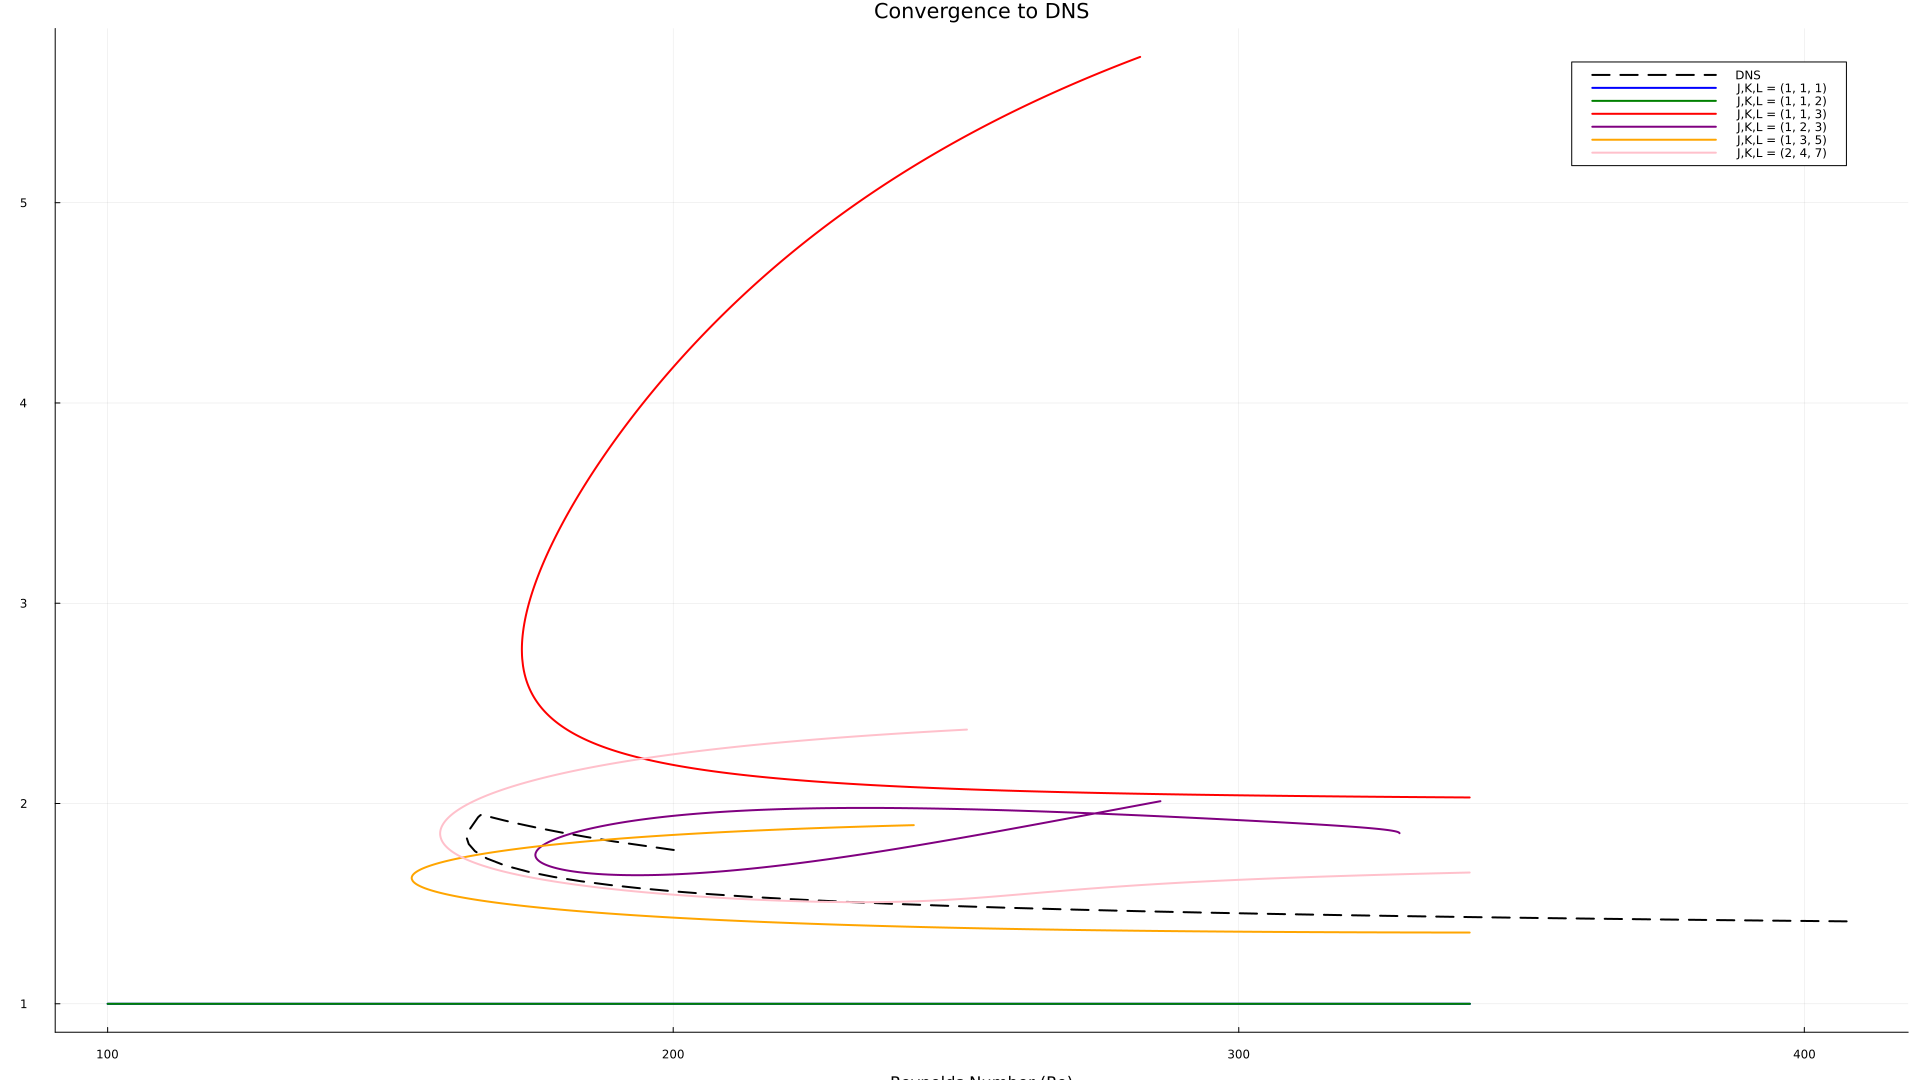

"/home/ebenq/Dev/julia/CloudAtlas.jl/notebooks/tw_bifurcations/convergence_plot.png"

In [9]:
display(p)
savefig("convergence_plot.png")

In [ ]:
using LinearAlgebra, Polynomials, Plots
using Revise, DelimitedFiles, BenchmarkTools
using CloudAtlas, BifurcationKit, ChannelflowWrapper
using CSV, DataFrames, Plots, Dates
"""
    myreaddlm(filename, cc='%')

Read matrix or vector from a file, dropping comments marked with cc.
"""
function myreaddlm(filename; cc='%')
    X = readdlm(filename, comments=true, comment_char=cc)
    if size(X,2) == 1
        X = X[:,1]
    end
    X
end

macro suppress(ex)
    quote
        local old_stdout = stdout
        redirect_stdout(devnull)
        try
            $(esc(ex))
        finally
            redirect_stdout(old_stdout)
        end
    end
end

In [14]:
sx, sy, sz, tx, tz = halfbox_symmetries()

# Parameters
hookparams = SearchParams(ftol=1e-08, xtol=1e-12, Nnewton=30,Nhook=8,δ=0.01, verbosity=0)
R = 200
cx0 = 0.000
cz0 = 0.009

α, γ = 1.0, 2.0
H = [(sx*sy)*(tx*tz)]
normalize = true

dns_file = "TW1-2pi1piRe200-40x49x40.nc"
# discretizations = [(1, 1, 2), (1, 1, 3), (1, 2, 3), (1, 3, 5), (2, 4, 7)]
discretizations = [(3, 5, 9)]

# CREATE OUTPUT DIRECTORY
output_dir = "bifurcation_data"
mkpath(output_dir)

"bifurcation_data"

In [10]:
"""
Continue a z-traveling wave (cx=0) solution branch in Reynolds number.
NOW SAVES DATA TO FILE AS IT RUNS.
"""
function tw_z_branch_continuation(model, ξ_0, Re0, output_file;
                                  Re_min=100.0, Re_max=500.0,
                                  max_steps=1000, tol=1e-10, dsmin=1e-7)
    m = model.m
    x0 = ξ_0[1:m]
    cx0 = ξ_0[m+1]
    cz0 = ξ_0[m+2]
    
    u0 = vcat(x0, cz0)
    Du0_z = model.Cz * x0
    
    function f_tw_z(u, p)
        (; Re) = p
        x  = u[1:m]
        cz = u[end] 

        res_flow = (cz .* (model.Cz * x)) .- (model.A1 * x) .- ((1/Re) .* (model.A2 * x)) .- model.N(x)
        res_phase = dot(x .- x0, Du0_z)
        
        return [res_flow; res_phase]
    end

    params = (Re = Re0, x0_param = x0, Du0_param = Du0_z)
    
    # MODIFIED: Add callback to save data during continuation
    function save_callback(x, f, J, res, iteration, itlinear, options; kwargs...)
        # This gets called at each successful step
        return true  # Continue continuation
    end
    
    prob = BifurcationProblem(
        f_tw_z, u0, params, (@optic _.Re);
        record_from_solution = (u, p_val; k...) -> (R=p_val, x=u[1:m], cx=0.0, cz=u[m+1], pow=shear(u[1:m], model))
    )
    
    opts = ContinuationPar(
        p_max=Re_max,
        p_min=Re_min,
        detect_bifurcation = 0,
        n_inversion=20,
        max_steps=max_steps,
        newton_options=NewtonPar(tol=tol, max_iterations=20),
        dsmin=dsmin
    )
    
    println("Starting Z-TW continuation from Re = $Re0...")
    branch = continuation(prob, PALC(), opts, bothside=true)
    println("Continuation complete. Found $(length(branch.branch)) points.")
    
    # SAVE DATA TO FILE
    println("Saving data to $output_file...")
    open(output_file, "w") do io
        # Write header
        println(io, "# Reynolds Number, Power Input, cz")
        println(io, "# Generated: $(now())")
        
        # Write data
        for point in branch.branch
            Re_val = point.param
            pow_val = point.pow
            cz_val = point.cz
            println(io, "$Re_val\t$pow_val\t$cz_val")
        end
    end
    println("Data saved successfully!")
    
    return branch
end

tw_z_branch_continuation

In [11]:
function compute_branch(J, K, L, udns_file; Re_start=200.0, α=1.0, γ=2.0, H=[(sx*sy)*(tx*tz)])
    model = TWModel(α, γ, J, K, L, H, normalize=true)
    m = length(model)
    println("Model dimension m = $m")

    filename_guess = "tmp_projection_J$(J)K$(K)L$(L).asc"
    x0 = field2coeff(model.ijkl, udns_file, filename_guess)
    cx0, cz0 = 0.000, 0.009
    ξ0 = [x0; cx0; cz0]

    println("Finding fixed point at Re=$Re_start...")
    g_closure(ξ) = model.g(ξ, Re_start)
    Dg_closure(ξ) = model.Dg(ξ, Re_start)
    ξ_final, converged = hookstepsolve(g_closure, Dg_closure, ξ0, hookparams)
    
    if !converged
        println("WARNING: Newton solver did not converge for $J,$K,$L")
        return nothing
    end

    # DEFINE OUTPUT FILE NAME
    output_file = joinpath(output_dir, "tw1ReD-$(J)-$(K)-$(L).asc")
    
    println("Running continuation...")
    branch = tw_z_branch_continuation(model, ξ_final, Re_start, output_file;
                                    Re_min=100.0, Re_max=500.0, max_steps=1000)
    
    return branch
end

compute_branch (generic function with 1 method)

In [ ]:
# --- Main Execution ---
println("\n" * "="^60)
println("Starting Bifurcation Analysis")
println("Output directory: $output_dir")
println("="^60)

branches = Dict()
colors = [:blue, :green, :red, :purple, :orange, :pink, :teal]

for (i, jkl) in enumerate(discretizations)
    J, K, L = jkl
    println("\n" * "="^60)
    println("Starting analysis for Resolution: J=$J, K=$K, L=$L")
    println("="^60)
    
    br = @suppress compute_branch(J, K, L, dns_file)
    
    if br !== nothing
        branches[(J,K,L)] = br
        println("✓ Branch for J=$J, K=$K, L=$L complete!")
    else
        println("✗ Branch for J=$J, K=$K, L=$L failed!")
    end
end


Starting Bifurcation Analysis
Output directory: bifurcation_data

Starting analysis for Resolution: J=3, K=5, L=9


In [ ]:
# --- Plotting (using saved data files) ---
println("\n" * "="^60)
println("Creating plot from saved data...")
println("="^60)

p = plot(
    xlabel = "Reynolds Number (Re)",
    ylabel = "Power Input",
    title = "Convergence to DNS",
    legend = :topright,
    grid = true,
    size=(1920, 1080)
)

# load DNS data
df_top = CSV.read("topbranch.asc", DataFrame; delim=' ', ignorerepeated=true)
df_bot = CSV.read("bottombranch.asc", DataFrame; delim=' ', ignorerepeated=true)
sort!(df_top, 1, rev=true) # Sort by Re descending
dns_data = vcat(df_top, df_bot)

# Plot DNS Data
plot!(p, dns_data[:,1], dns_data[:,2], 
    label="DNS", color=:black, linewidth=2, linestyle=:dash)

# Plot each saved branch
for (i, (J, K, L)) in enumerate(discretizations)
    datafile = joinpath(output_dir, "tw1ReD-$(J)-$(K)-$(L).asc")
    
    if isfile(datafile)
        data = myreaddlm(datafile, cc='#')
        plot!(p, data[:,1], data[:,2],
            label="J,K,L = $((J,K,L))",
            linewidth=2,
            color=colors[mod1(i, length(colors))]
        )
        println("✓ Plotted data from $datafile")
    else
        println("✗ File not found: $datafile")
    end
end

display(p)
savefig(joinpath(output_dir, "convergence_plot.png"))
println("\nPlot saved to $(joinpath(output_dir, "convergence_plot.png"))")

println("\n" * "="^60)
println("All bifurcation data saved in: $output_dir")
println("="^60)

In [ ]:
1+2